In [61]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import re
import numpy as np
import sys

sys.path.insert(0, "../Modules")

from utils import describe_dataframe

pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [62]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/Grid Level/data'

In [63]:
NUTS2 = 'Thrace'
YEAR = '2025'

In [64]:
df = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding=enc)

In [65]:
df.head()

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,indices_lat,indices_lon,ndvi_new,ndmi_new,ndwi_new,ndbi_new,ndvi_mean_new,ndmi_mean_new,ndwi_mean_new,ndbi_mean_new,ndvi_std_new,ndmi_std_new,ndwi_std_new,ndbi_std_new,lst_image_date,lst_lat,lst_lon,lst_day_new,lst_night_new,indices_image_date.1,indices_lat.1,indices_lon.1,dt_placement_minus_1,dt_placement_minus_1_avail,rainfall_new
0,23.65882,41.33542,0,2025-01-01,EL51,2025,1,2025-01-27,41.333732,23.659379,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01,41.333732,23.659379,13893.0,13684.0,2025-01-01,41.350189,23.650108,2024-12-31,2024-12-31,0.00
1,23.65882,41.33542,0,2025-01-02,EL51,2025,1,2025-01-02,41.333732,23.659379,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,2025-01-02,41.333732,23.659379,13803.0,13667.0,2025-01-02,41.350189,23.650108,2025-01-01,2025-01-01,0.00
2,23.65882,41.33542,0,2025-01-03,EL51,2025,1,2025-01-02,41.333732,23.659379,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,2025-01-03,41.333732,23.659379,13803.0,13667.0,2025-01-03,41.350189,23.650108,2025-01-02,2025-01-02,6.45
3,23.65882,41.33542,0,2025-01-04,EL51,2025,1,2025-01-02,41.333732,23.659379,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,2025-01-04,41.333732,23.659379,13803.0,13546.0,2025-01-04,41.350189,23.650108,2025-01-03,2025-01-03,4.76
4,23.65882,41.33542,0,2025-01-05,EL51,2025,1,2025-01-02,41.333732,23.659379,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,2025-01-05,41.333732,23.659379,13803.0,13649.0,2025-01-05,41.350189,23.650108,2025-01-04,2025-01-04,2.02


<Axes: >

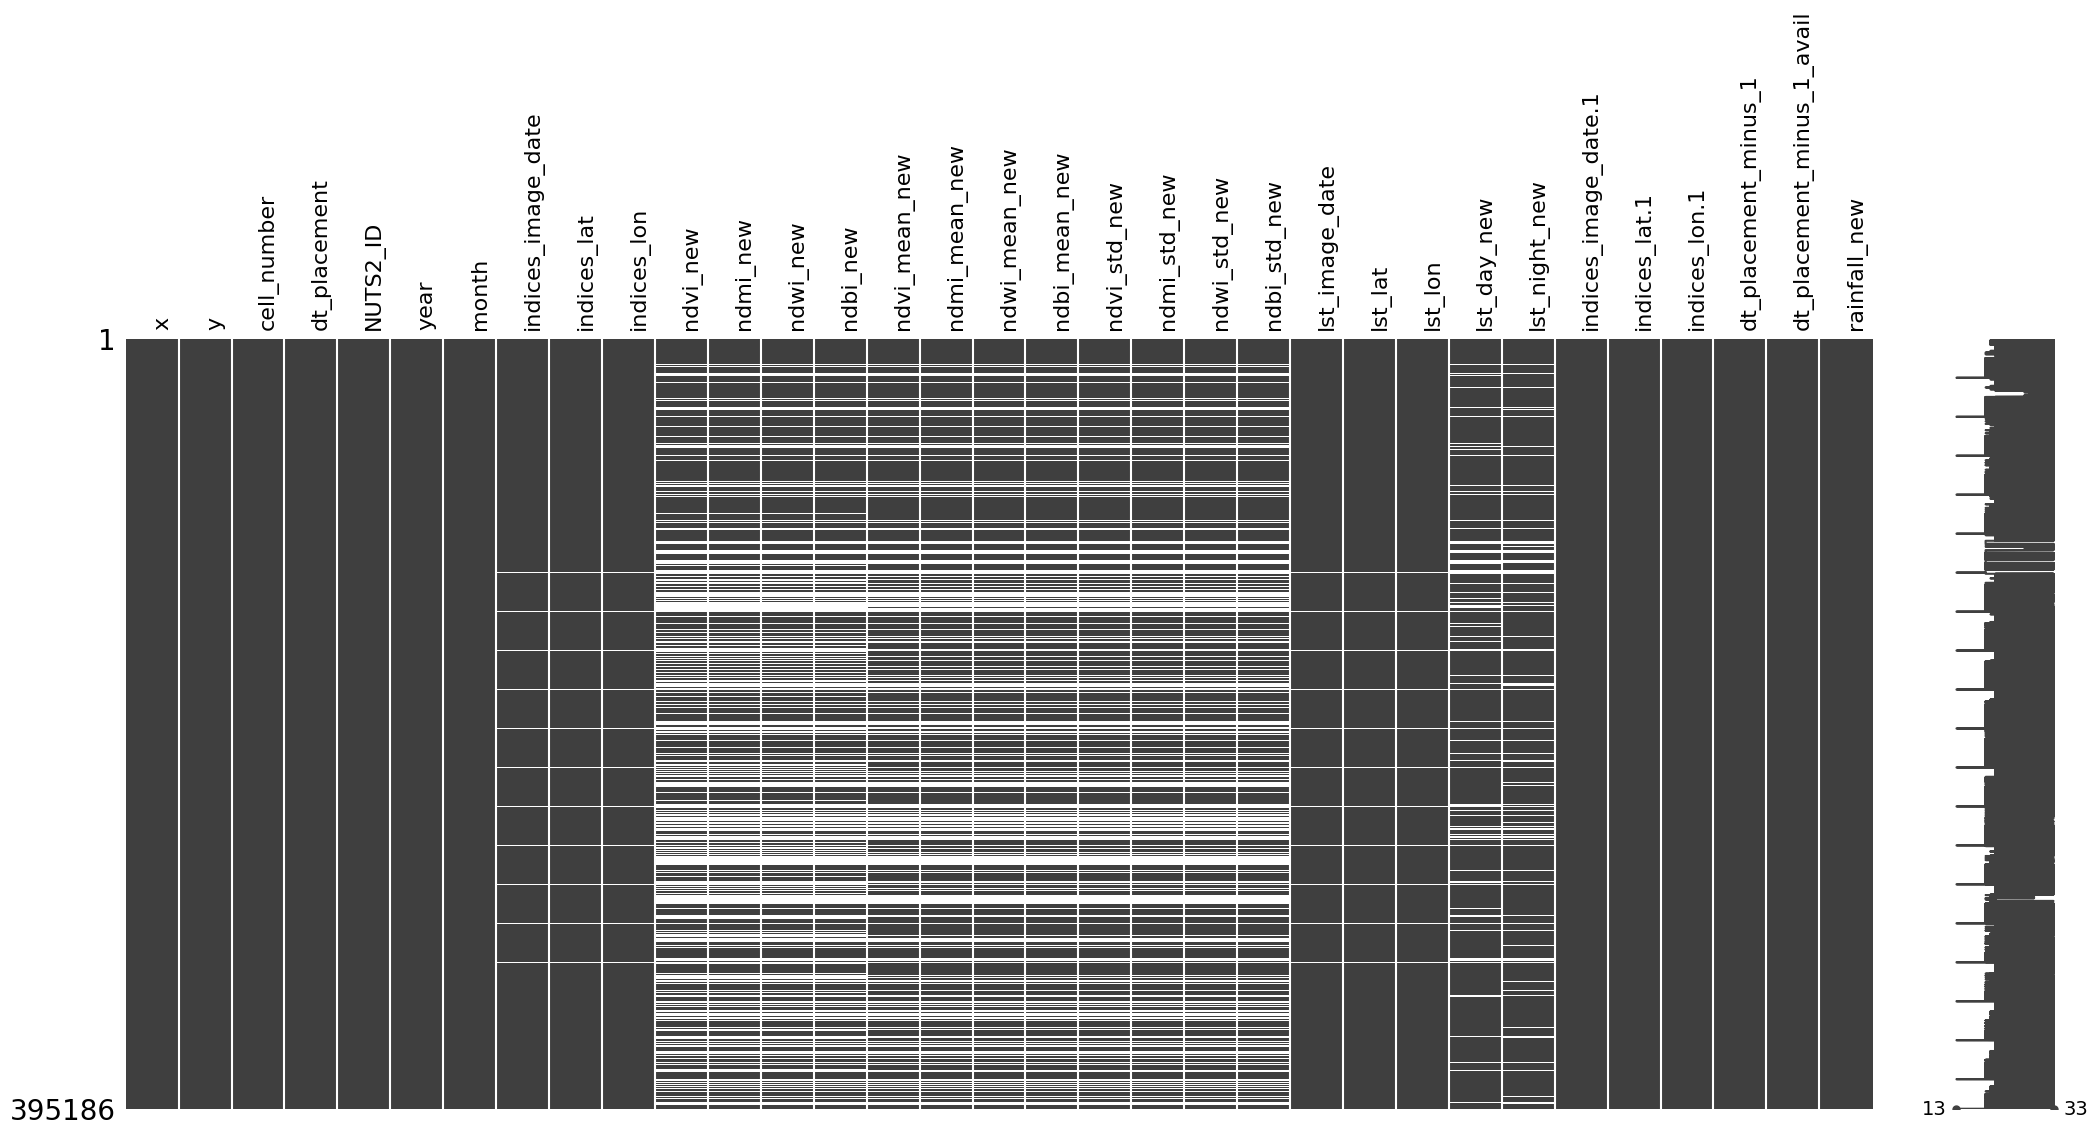

In [66]:
msno.matrix(df, label_rotation=90)

In [67]:
df.drop(['indices_lat', 'indices_lon', 'lst_lat', 'lst_lon', 'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_1'], axis = 1, inplace=True)

In [68]:
df.rename(columns={"dt_placement_minus_1_avail" : "rainfall_image_date"}, errors="raise", inplace=True)

In [69]:
df = df.rename(columns=lambda x: re.sub('_new', '', x))

In [70]:
df['dt_placement']= pd.to_datetime(df['dt_placement'])
df['indices_image_date']= pd.to_datetime(df['indices_image_date'])
df['lst_image_date']= pd.to_datetime(df['lst_image_date'])
df['rainfall_image_date']= pd.to_datetime(df['rainfall_image_date'])

In [71]:
df

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,indices_image_date,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_image_date,lst_day,lst_night,rainfall_image_date,rainfall
0,23.65882,41.33542,0,2025-01-01,EL51,2025,1,2025-01-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-01,13893.0,13684.0,2024-12-31,0.00
1,23.65882,41.33542,0,2025-01-02,EL51,2025,1,2025-01-02,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,2025-01-02,13803.0,13667.0,2025-01-01,0.00
2,23.65882,41.33542,0,2025-01-03,EL51,2025,1,2025-01-02,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,2025-01-03,13803.0,13667.0,2025-01-02,6.45
3,23.65882,41.33542,0,2025-01-04,EL51,2025,1,2025-01-02,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,2025-01-04,13803.0,13546.0,2025-01-03,4.76
4,23.65882,41.33542,0,2025-01-05,EL51,2025,1,2025-01-02,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,2025-01-05,13803.0,13649.0,2025-01-04,2.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395181,26.58397,41.49712,3261,2025-05-01,EL51,2025,5,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2025-04-29,0.00
395182,26.60756,41.35339,3262,2025-05-01,EL51,2025,5,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2025-04-29,0.00
395183,26.60756,41.37135,3263,2025-05-01,EL51,2025,5,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2025-04-29,0.00
395184,26.60756,41.38932,3264,2025-05-01,EL51,2025,5,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,2025-04-29,0.00


<Axes: >

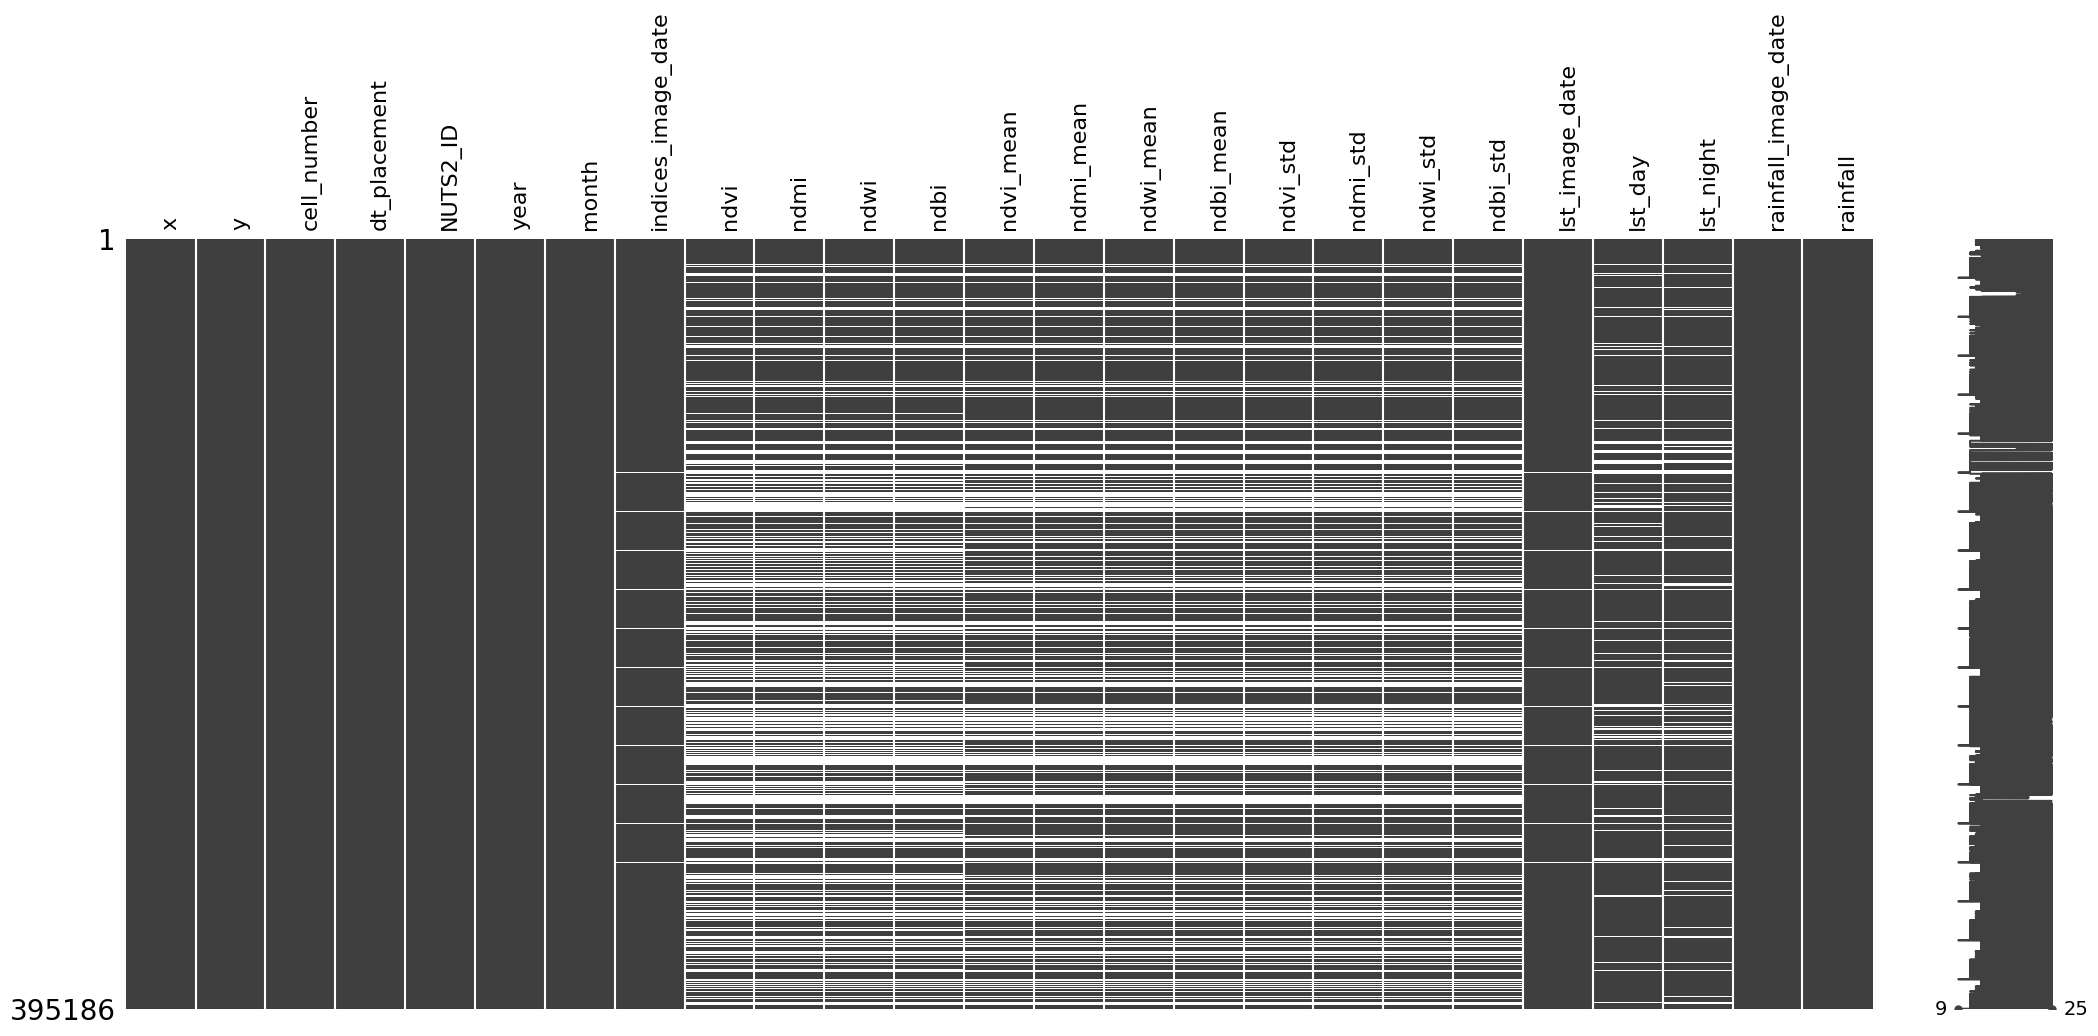

In [72]:
msno.matrix(df, label_rotation=90)

In [73]:
df2 = df.copy()

In [74]:
indices_mask = df2['indices_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=7))
lst_mask = df2['lst_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))
rainfall_mask = df2['rainfall_image_date'] < (df2['dt_placement'] - pd.Timedelta(days=1))

indices_columns = ['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean',
                  'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std']

lst_columns = ['lst_day', 'lst_night']

rainfall_columns = ['rainfall']

df2.loc[indices_mask, indices_columns] = np.nan
df2.loc[lst_mask, lst_columns] = np.nan
df2.loc[rainfall_mask, rainfall_columns] = np.nan

<Axes: >

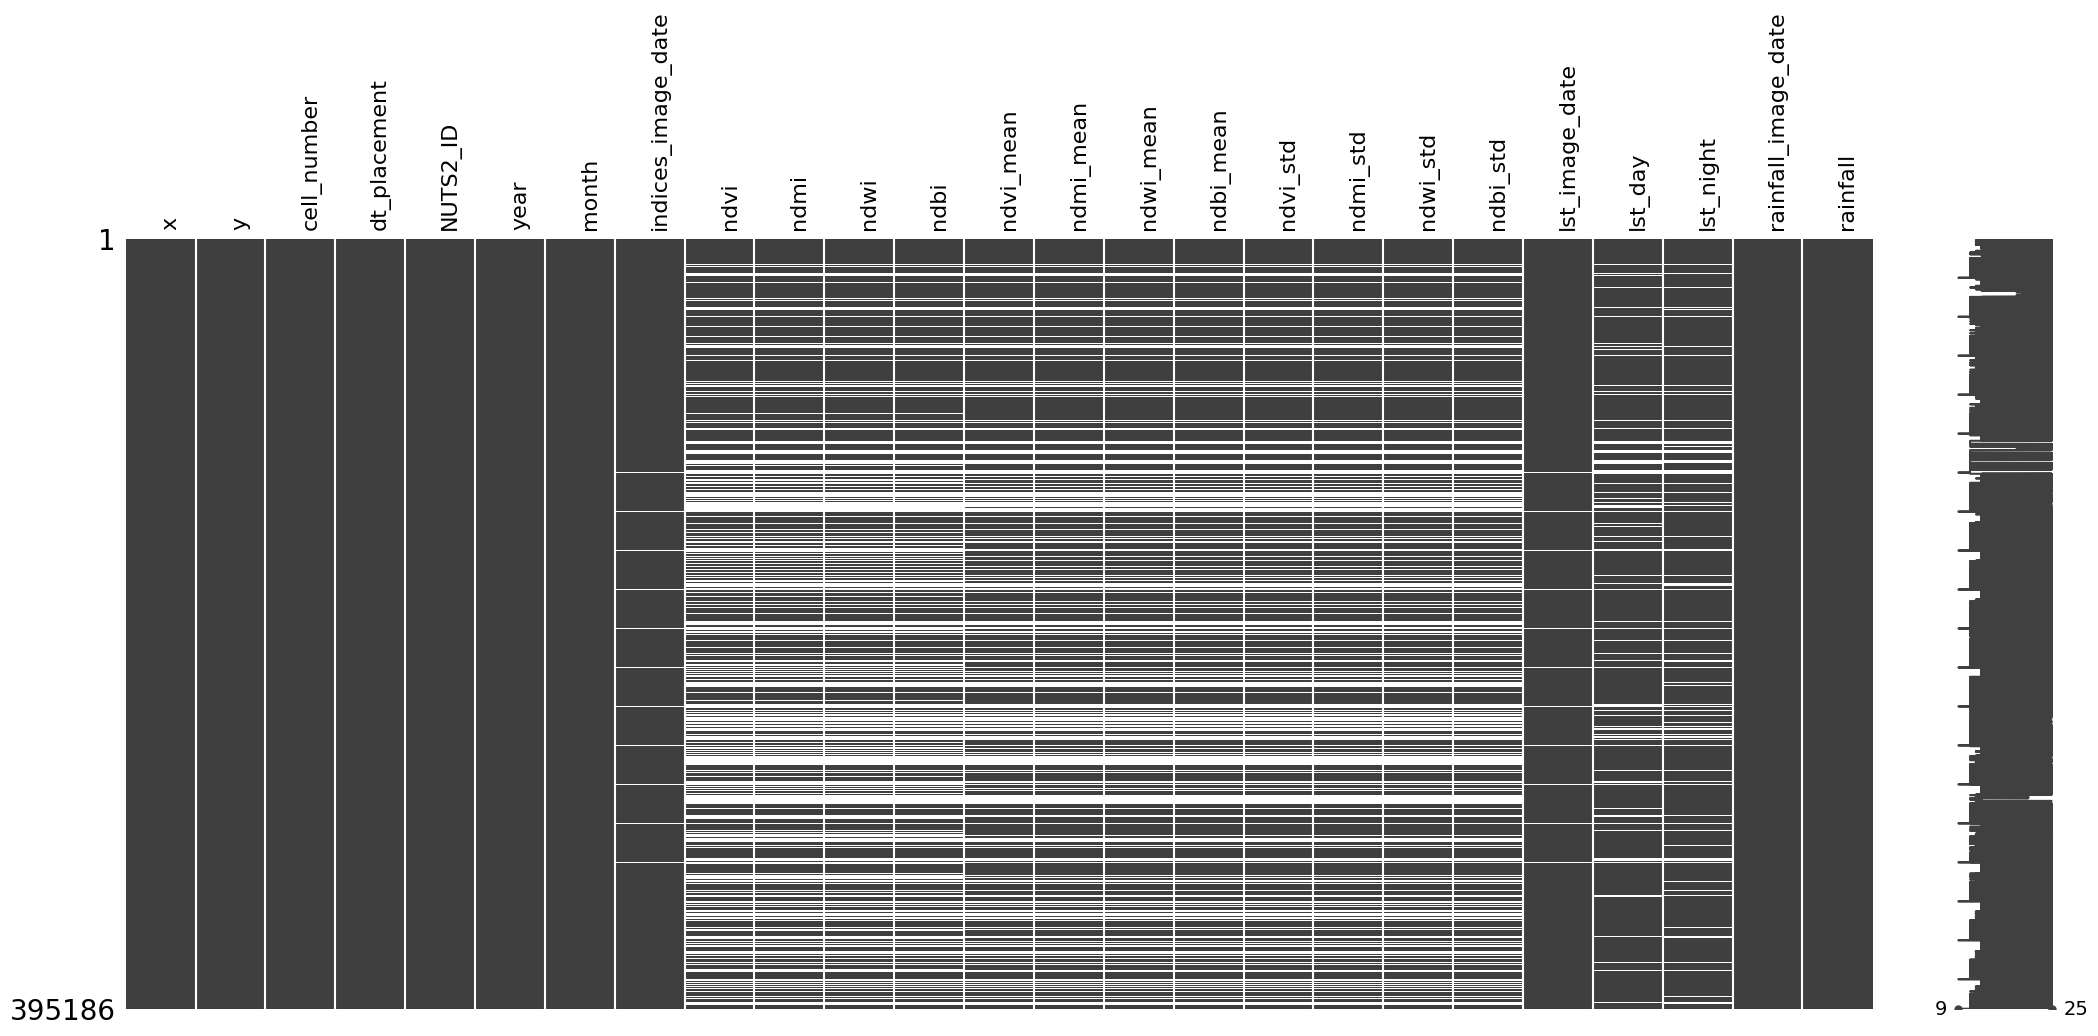

In [75]:
msno.matrix(df, label_rotation=90)

In [76]:
describe_dataframe(df2, remove_zeros=True)

,Column,Missing
7,indices_image_date,0.8264
8,ndvi,39.5895
9,ndmi,39.5895
10,ndwi,39.5895
11,ndbi,39.5895
12,ndvi_mean,34.9200
13,ndmi_mean,34.9200
14,ndwi_mean,34.9200
15,ndbi_mean,34.9200
16,ndvi_std,34.9200


In [77]:
df2.drop(['indices_image_date', 'lst_image_date', 'rainfall_image_date'], axis = 1, inplace=True)

In [78]:
df2.reset_index(drop=True, inplace=True)

In [79]:
df2

,x,y,cell_number,dt_placement,NUTS2_ID,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall
0,23.65882,41.33542,0,2025-01-01,EL51,2025,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13893.0,13684.0,0.00
1,23.65882,41.33542,0,2025-01-02,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13667.0,0.00
2,23.65882,41.33542,0,2025-01-03,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13667.0,6.45
3,23.65882,41.33542,0,2025-01-04,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13546.0,4.76
4,23.65882,41.33542,0,2025-01-05,EL51,2025,1,0.078916,0.146433,0.098425,-0.146433,0.183488,0.07095,-0.082637,-0.07095,0.087655,0.112251,0.13884,0.112251,13803.0,13649.0,2.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395181,26.58397,41.49712,3261,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
395182,26.60756,41.35339,3262,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
395183,26.60756,41.37135,3263,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
395184,26.60756,41.38932,3264,2025-05-01,EL51,2025,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
df2.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_GRID_{YEAR}_filled.csv', encoding='utf-8')